# Uncertainty-aware time-series forecasting with modular Bayesian pipelines via ProbPipe

In [1]:
"""DataLoader Node
   ↓
TrainTestSplitNode
   ↓
SeasonalFeatureNode
   ↓
BayesianRegressionModel
   ↓
InferenceNode 
   ↓
PosteriorPredictiveNode
   ↓
DiagnosticsNode"""

'DataLoader Node\n   ↓\nTrainTestSplitNode\n   ↓\nSeasonalFeatureNode\n   ↓\nBayesianRegressionModel\n   ↓\nInferenceNode \n   ↓\nPosteriorPredictiveNode\n   ↓\nDiagnosticsNode'

In [ ]:
from probpipe.core.node import Node, wf, abstractwf, Workflow, Module, AbstractModule
from probpipe import MvNormal
from probpipe import EmpiricalDistribution, Distribution
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from abc import ABC


## Abstract Interfaces

In [ ]:
class DataSource(AbstractModule):
    @abstractwf
    def load(self) -> tuple[object, EmpiricalDistribution]:
        ...

class Splitter(AbstractModule):
    @abstractwf
    def split(self, timestamps, y: EmpiricalDistribution):
        ...

class FeatureBuilder(AbstractModule):
    @abstractwf
    def build(self, ts_train, ts_test):
        ...

class InferenceMethod(AbstractModule):
    @abstractwf
    def infer(self, X_train, y_train: EmpiricalDistribution) -> EmpiricalDistribution:
        ...

class PosteriorPredictive(AbstractModule):
    @abstractwf
    def predict(self, posterior: Distribution, X_test) -> EmpiricalDistribution:
        ...

class Diagnostics(AbstractModule):
    @abstractwf
    def diagnose(self, predictive: EmpiricalDistribution, y_true: EmpiricalDistribution, plot: bool = True):
        ...

class Approximation(AbstractModule):
    @abstractwf
    def approximate(self, posterior: Distribution) -> MvNormal:
        ...

## DataLoader Node

In [5]:
# import the dataset from UC Irvine's data repository
from ucimlrepo import fetch_ucirepo 
# if not installed yet: pip install ucimlrepo

In [6]:
class PM25DataLoaderNode(DataSource):
    def __init__(self, dataset_id: int | None = None, csv_path: str | None = None):
        super().__init__(dataset_id=dataset_id, csv_path=csv_path)

    @wf
    def load(self, dataset_id: int | None = None, csv_path: str | None = None):
        if csv_path:
            df = pd.read_csv(csv_path)
        elif dataset_id is not None:
            dataset = fetch_ucirepo(id=int(dataset_id))
            df = dataset.data.original  
        else:
            raise ValueError("Either enter an id or csv file path")

        timestamps = pd.to_datetime(df[["year", "month", "day", "hour"]]).to_numpy()

        pm25 = df["pm2.5"].replace(-999, np.nan).astype(float)
        mask = ~pm25.isna()

        y = pm25[mask].to_numpy()
        ts = timestamps[mask]

        return ts, EmpiricalDistribution(y[None, :])

## Train/Test Split Node

In [7]:
class TrainTestSplitNode(Splitter):
    """
    Splits (timestamps, y_dist) into train/test segments.
    """

    def __init__(self, test_horizon: int):
        super().__init__(test_horizon=int(test_horizon))

    @wf
    def split(self, timestamps, y: EmpiricalDistribution, test_horizon: int):
        y_samples = y.samples
        T = y_samples.shape[1]
        H = int(test_horizon) 

        if H <= 0 or H >= T:
            raise ValueError("Invalid test horizon.")

        split_idx = T - H
        ts_train, ts_test = timestamps[:split_idx], timestamps[split_idx:]
        y_train, y_test = y_samples[:, :split_idx], y_samples[:, split_idx:]

        return ts_train, EmpiricalDistribution(y_train), ts_test, EmpiricalDistribution(y_test)

## Bayesian linear regression with seasonal features

$$ y_t = \beta_0 + \beta_1 t + \beta_2 sin(\frac{2\pi t}{24}) + \beta_3 cos(\frac{2\pi t}{24}) + \beta_4 sin(\frac{2\pi t}{365 \times 24}) + \beta_5 cos(\frac{2\pi t}{365 \times 24}) + \epsilon_t$$

where, 
$$\epsilon_t \sim \mathcal{N}(0, \sigma^2) $$

Namely, the model includes an intercept, a linear trend, and daily and yearly seasonal components, using sine and cosine features.

In [8]:
class SeasonalFeatureNode(FeatureBuilder):
    """
    Builds seasonal design matrices.
    """
    def __init__(self):
        super().__init__()
        
    @wf
    def build(self, ts_train, ts_test):
        n_train = len(ts_train)
        n_test = len(ts_test)

        t_train = np.arange(n_train)
        t_test = np.arange(n_train, n_train + n_test)

        def design(t):
            return np.column_stack([
                np.ones_like(t, dtype=float),
                t.astype(float),
                np.sin(2*np.pi*t/24.0),
                np.cos(2*np.pi*t/24.0),
                np.sin(2*np.pi*t/(365.0*24.0)),
                np.cos(2*np.pi*t/(365.0*24.0)),
            ])

        return design(t_train), design(t_test)


## Conjugate Bayesian Linear Regression Inference Node

In [9]:
class ConjugateBLRInferenceNode(InferenceMethod):
    """
    Bayesian linear regression with Normal-Inverse-Gamma prior.
    Returns EmpiricalDistribution of posterior samples:
      samples shape (S, D+1), last column is sigma.
    """

    def __init__(self, num_samples=2000, a0=2.0, b0=2.0, v0_scale=10.0):
        super().__init__(
            num_samples=int(num_samples),
            a0=float(a0),
            b0=float(b0),
            v0_scale=float(v0_scale),
        )

    @wf
    def infer(self, X_train, y_train: EmpiricalDistribution, num_samples: int, a0: float, b0: float, v0_scale: float):
        X = np.asarray(X_train)
        y = y_train.samples[0]   # shape (N,)

        N, D = X.shape

        m0 = np.zeros(D)
        V0 = (v0_scale**2) * np.eye(D)
        V0_inv = np.linalg.inv(V0)

        XtX = X.T @ X
        Vn_inv = V0_inv + XtX
        Vn = np.linalg.inv(Vn_inv)

        Xty = X.T @ y
        mn = Vn @ (V0_inv @ m0 + Xty)

        a_n = a0 + N / 2.0
        yty = float(y.T @ y)
        m0_term = float(m0.T @ V0_inv @ m0)
        mn_term = float(mn.T @ Vn_inv @ mn)
        b_n = b0 + 0.5 * (yty + m0_term - mn_term)

        gamma = np.random.gamma(shape=a_n, scale=1.0/b_n, size=num_samples)
        sigma2 = 1.0 / gamma
        sigma = np.sqrt(sigma2)

        L = np.linalg.cholesky(Vn)
        z = np.random.normal(size=(num_samples, D))
        beta = mn[None, :] + sigma[:, None] * (z @ L.T)

        samples = np.column_stack([beta, sigma])
        return EmpiricalDistribution(samples)

##  Posterior Predictive Node

In [10]:
class PosteriorPredictiveNode(PosteriorPredictive):
    """
    Generates posterior predictive samples.
    """
    def __init__(self):
        super().__init__()
    
    @wf
    def predict(self, posterior: EmpiricalDistribution, X_test):
        post = posterior.samples
        X = np.asarray(X_test)

        beta = post[:, :-1]
        sigma = post[:, -1]

        mu = beta @ X.T
        noise = np.random.normal(size=mu.shape) * sigma[:, None]
        y_pred = mu + noise

        return EmpiricalDistribution(y_pred)

## Gaussian Approximation Node 


In [11]:
class GaussianApproximationNode(Approximation):
    """
    Converts an arbitrary Distribution into a multivariate Gaussian.
    """
    def __init__(self, num_samples: int = 2048):
        super().__init__(num_samples=int(num_samples))

    @wf
    def approximate(self, posterior: Distribution, num_samples: int) -> MvNormal:
        return MvNormal.from_distribution(posterior, num_samples=num_samples)

## Coverage Diagnostics Node

In [12]:
class CoverageDiagnosticsNode(Diagnostics):
    """
    Computes and plots predictive interval coverage.
    """

    def __init__(self, levels=(0.5, 0.8, 0.9)):
        super().__init__(levels=tuple(levels))

    @wf
    def diagnose(self, predictive: EmpiricalDistribution, y_true: EmpiricalDistribution, plot: bool=True, levels=(0.5,0.8,0.9)):
        samples = predictive.samples
        y = y_true.samples[0]

        coverages = {}
        for lvl in levels:
            lo = np.quantile(samples, (1-lvl)/2, axis=0)
            hi = np.quantile(samples, 1-(1-lvl)/2, axis=0)
            coverages[lvl] = float(((y >= lo) & (y <= hi)).mean())

        if plot:
            xs = np.array(list(coverages.keys()))
            ys = np.array(list(coverages.values()))

            plt.figure(figsize=(5,5))
            plt.plot(xs, ys, "o-", label="Empirical")
            plt.plot([0,1], [0,1], "--", label="Ideal")
            plt.xlabel("Nominal Coverage")
            plt.ylabel("Empirical Coverage")
            plt.title("Predictive Interval Coverage")
            plt.legend()
            plt.tight_layout()
            plt.show()

        return coverages

## Forecasting Module

This module aggregates workflow nodes above


In [ ]:
class PM25ForecastingModule(Module):

    @wf
    def fit(
        self,
        data: DataSource,
        split: Splitter,
        features: FeatureBuilder,
        inference: InferenceMethod,
    ) -> EmpiricalDistribution:
        ts, y = data.load()
        ts_tr, y_tr, ts_te, y_te = split.split(timestamps=ts, y=y)
        X_tr, X_te = features.build(ts_train=ts_tr, ts_test=ts_te)
        return inference.infer(X_train=X_tr, y_train=y_tr)

    @wf
    def predict(
        self,
        data: DataSource,
        split: Splitter,
        features: FeatureBuilder,
        ppred: PosteriorPredictive,
        posterior: Distribution,
    ) -> EmpiricalDistribution:
        ts, y = data.load()
        ts_tr, y_tr, ts_te, y_te = split.split(timestamps=ts, y=y)
        X_tr, X_te = features.build(ts_train=ts_tr, ts_test=ts_te)
        return ppred.predict(posterior=posterior, X_test=X_te)

    @wf
    def diagnose(
        self,
        data: DataSource,
        split: Splitter,
        diag: Diagnostics,
        predictive: EmpiricalDistribution,
    ):
        ts, y = data.load()
        ts_tr, y_tr, ts_te, y_te = split.split(timestamps=ts, y=y)
        return diag.diagnose(predictive=predictive, y_true=y_te, plot=True)

    @wf
    def fit_gaussian(
        self,
        data: DataSource,
        split: Splitter,
        features: FeatureBuilder,
        inference: InferenceMethod,
        approx: Approximation,
    ) -> MvNormal:
        posterior_emp = self.fit(data=data, split=split, features=features, inference=inference)
        return approx.approximate(posterior=posterior_emp)

### Helper functions

In [12]:
def plot_forecast_with_uncertainty(
    predictive,
    y_true,
    *,
    title="PM2.5 Forecast with Predictive Uncertainty",
    ylabel="PM2.5",
    xlabel="Time (test window)",
):
    """
    Plots posterior predictive mean and uncertainty bands.

    Args:
        predictive: EmpiricalDistribution with samples shape (S, T)
        y_true: EmpiricalDistribution with samples shape (1, T)
    """
    samples = predictive.samples          # (S, T)
    y = y_true.samples[0]                  # (T,)

    t = np.arange(len(y))

    # Predictive summaries
    mean = samples.mean(axis=0)
    lo_80 = np.quantile(samples, 0.10, axis=0)
    hi_80 = np.quantile(samples, 0.90, axis=0)
    lo_90 = np.quantile(samples, 0.05, axis=0)
    hi_90 = np.quantile(samples, 0.95, axis=0)

    plt.figure(figsize=(10, 4))

    # Uncertainty bands
    plt.fill_between(t, lo_90, hi_90, color="C0", alpha=0.20, label="90% credible interval")
    plt.fill_between(t, lo_80, hi_80, color="C0", alpha=0.35, label="80% credible interval")

    # Mean prediction
    plt.plot(t, mean, color="C0", lw=2, label="Posterior predictive mean")

    # Observed data
    plt.plot(t, y, color="black", lw=1.5, label="Observed PM2.5")

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

## Creating the Workflow Nodes

In [14]:
data = PM25DataLoaderNode(dataset_id=381)
split = TrainTestSplitNode(test_horizon=24*14)
features = SeasonalFeatureNode()
inference = ConjugateBLRInferenceNode(num_samples=3000)
ppred = PosteriorPredictiveNode()
diag = CoverageDiagnosticsNode()

## Creating the Module

Now the module is the parent of the workflow nodes. Module has now access to call its children.

In [15]:
#old way of creating a module node- nodes should be explicitly given in child_nodes
"""pipe = PM25ForecastingModule(
        child_nodes = {
            "data": data,
            "split": split,
            "features": features,
            "inference": inference,
            "ppred": ppred,
            "diag": diag,
            "approx": GaussianApproximationNode(), 
        },
        inputs={},
        workflow_kind=None, #workflow_kind!!!
    )"""

# new way of defining a module node: no need for distinct treatment for nodes and other types of inputs

pipe = PM25ForecastingModule(
        data= data,
        split=split,
        features=features,
        inference=inference,
        ppred=ppred,
        diag=diag,
        approx=GaussianApproximationNode(), 
        workflow_kind=None, #workflow_kind!!!
    )


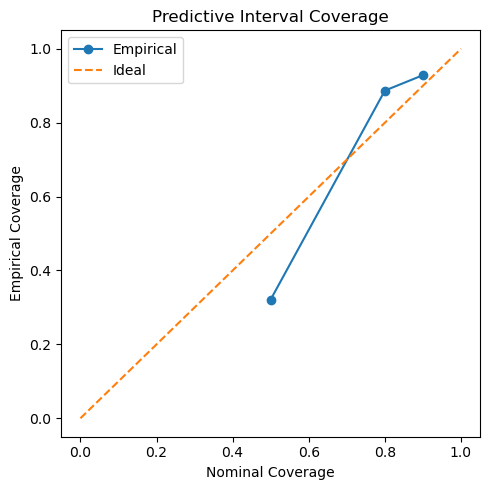

In [16]:
posterior_emp = pipe.fit()
# posterior_gauss = pipe.fit_gaussian()

predictive1 = pipe.predict(posterior=posterior_emp)
#predictive2 = pipe.predict(posterior=posterior_gauss)

coverage = pipe.diagnose(predictive=predictive1)

Note: ProbPipe is also designed to integrate with Prefect for orchestration. Above, I set workflow_kind=None, which means everything runs as normal Python code. But if I switch this flag, the same workflow nodes can automatically run as Prefect tasks or flows, without changing the model code.

## Fit & Predict

In [15]:
print("Coverage:", coverage)

Coverage: {0.5: 0.3273809523809524, 0.8: 0.8869047619047619, 0.9: 0.9345238095238095}


## Forecasting using empirical posterior

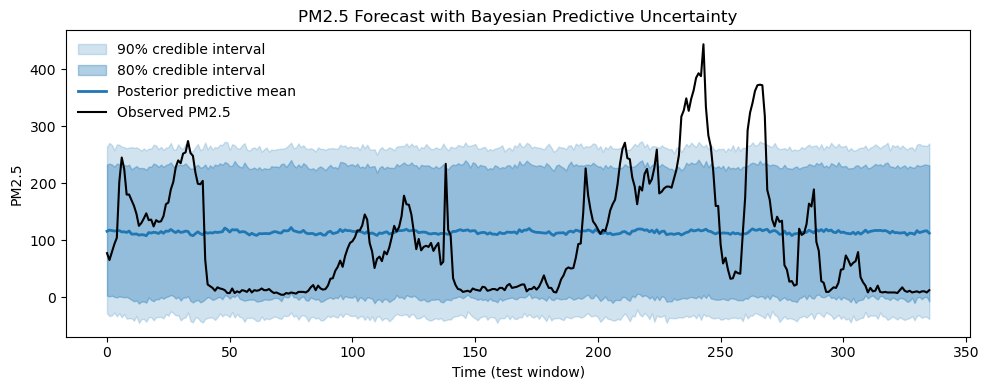

In [16]:
ts, y = data()
ts_tr, y_tr, ts_te, y_te = split(timestamps=ts, y=y)

plot_forecast_with_uncertainty(
    predictive=predictive1,
    y_true=y_te,
    title="PM2.5 Forecast with Bayesian Predictive Uncertainty",
)

## Visualization of the dependency graph

Modules are rendered as clusters. Workflow nodes are inside the module.

Child nodes are outside the module, their relationship are shown with dependency edges:

(from **dependency** to **dependent**)

**Note: this is a dependency graph, not a call graph!**

In [17]:
dot = pipe.dag()

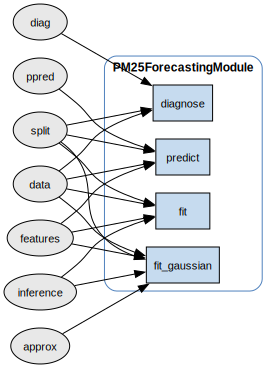

In [18]:
display(pipe.dag())